In [505]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Permutation testing

1. Generate observations for conditions a & b
2. Calculate the difference in means of distributions a & b
3. Combing observations into 1 vector
4. Create separate vector of condition labels for the combined conditions
5. Calculate a distribution of mean differences with 1000 iterations of the following
- Randomly assign conditions a & b to the combined observations
- Calculate the difference of means between the newly assigned distributions
6. Compute the probability of the mean diff of a & b, given the distribution of mean differences

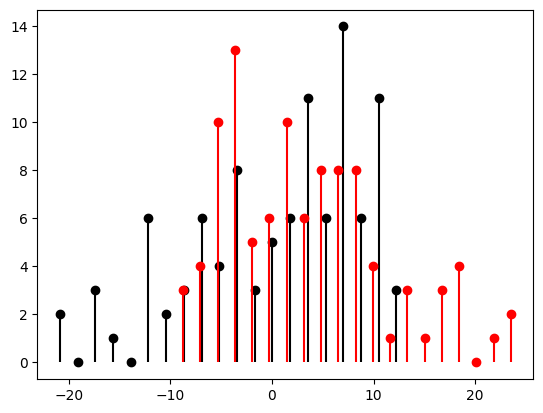

In [506]:
# 1. Generate observations for conditions a & b

# Number of trials
n = 100
variance = 10
shift = 2

random_samples = np.random.randn(n)
random_samples[random_samples>0] = np.log(1+random_samples[random_samples>0])
data_a = shift + random_samples * variance

random_samples = np.random.randn(n)
random_samples[random_samples>0] = np.log(1+random_samples[random_samples>0])
data_b = shift - random_samples * variance

ya, xa = np.histogram(data_a, 20)
xa = (xa[:-1]+xa[1:])/2

yb, xb = np.histogram(data_b, 20)
xb = (xb[:-1]+xb[1:])/2

fig_a, ax_a = plt.subplots()

ax_a.stem(xa, ya, 'ko', basefmt=' ',  label="Data A")
ax_a.stem(xb, yb, 'ro', basefmt=' ',  label="Data B")

fig_a.show()

In [507]:
# Permutation Testing

def permutation(data):
    rand_conditions = np.array([np.random.randint(2) for _ in data])
    pop_mean = np.mean(data[rand_conditions == 1]) - np.mean(data[rand_conditions == 0])
    return pop_mean

def permutation_test(data, permutations = 1000):
    if permutations <= 1:
        return np.array([permutation(data)])
    else:
        return np.hstack((permutation(data), permutation_test(data, permutations - 1)))


## two methods of evaluating statistical significance

# Calculate probability
# Z-scale
z = lambda observed_diff, permutation_diffs: (observed_diff - np.mean(permutation_diffs)) / np.std(permutation_diffs, ddof=1)
p = lambda z: 1 - stats.norm.cdf(abs(z))

# Count NOTE this is wrong
def prob_count(observed_mean, means_dist):
    total = np.sum(means_dist[means_dist >= abs(observed_mean)])
    return total / means_dist.size

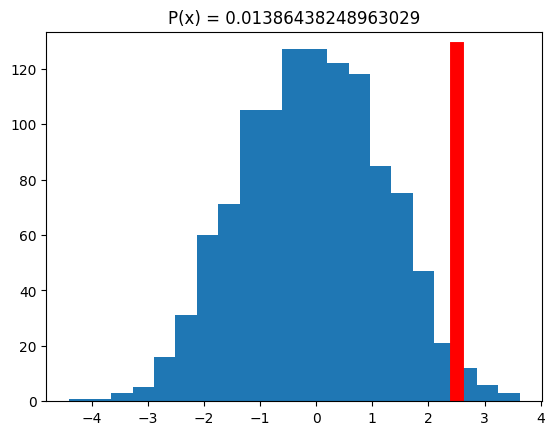

In [508]:
# 2. Calculate the difference in means of distributions a & b
# 3. Combing observations into 1 vector
# 4. Create separate vector of condition labels for the combined conditions

samples = np.hstack((data_a, data_b))
sample_conditions = np.hstack((np.zeros(len(data_a)), np.ones(len(data_b))))
mean_diff = np.mean(samples[sample_conditions == 1]) - np.mean(samples[sample_conditions == 0])

mean_distribution = permutation_test(samples)

prob_z = p(z(mean_diff, mean_distribution))
prob_count = prob_count(mean_diff, mean_distribution)

fig_b, ax_b = plt.subplots()

y, x = np.histogram(mean_distribution, 20)
x = (x[:-1]+x[1:])/2

ax_b.bar(x, y)
ax_b.plot([mean_diff, mean_diff], [np.min(y), np.max(y)], 'r', linewidth=10)
ax_b.set_title(f"P(x) = {prob_z}")

fig_b.show()

In [509]:
# 1. Create vector of different permutation number
permutations = np.arange(1, 200)
# 2. For each permutation number
# 3. Run permutation_test
# 4. Calculate the z value
# 5. Store z values in results vector

def permutation_tests(observations_a, observations_b, test_permutations):
    z_distribution = np.zeros(test_permutations.size)
    samples = np.hstack((observations_a, observations_b))
    sample_conditions = np.hstack((np.zeros(len(observations_a)), np.ones(len(observations_b))))
    mean_diff = np.mean(samples[sample_conditions == 1]) - np.mean(samples[sample_conditions == 0])

    for index, test in enumerate(test_permutations):
        print(f"Running permutation test with {test} permutations")
        z_distribution[index] = z(mean_diff, permutation_test(samples, test))

    return z_distribution

z_dist = permutation_tests(data_a, data_b, permutations)

Running permutation test with 1 permutations
Running permutation test with 2 permutations
Running permutation test with 3 permutations
Running permutation test with 4 permutations
Running permutation test with 5 permutations
Running permutation test with 6 permutations
Running permutation test with 7 permutations
Running permutation test with 8 permutations
Running permutation test with 9 permutations
Running permutation test with 10 permutations
Running permutation test with 11 permutations
Running permutation test with 12 permutations
Running permutation test with 13 permutations
Running permutation test with 14 permutations
Running permutation test with 15 permutations
Running permutation test with 16 permutations
Running permutation test with 17 permutations
Running permutation test with 18 permutations
Running permutation test with 19 permutations
Running permutation test with 20 permutations
Running permutation test with 21 permutations
Running permutation test with 22 permutatio

Text(0, 0.5, 'Count')

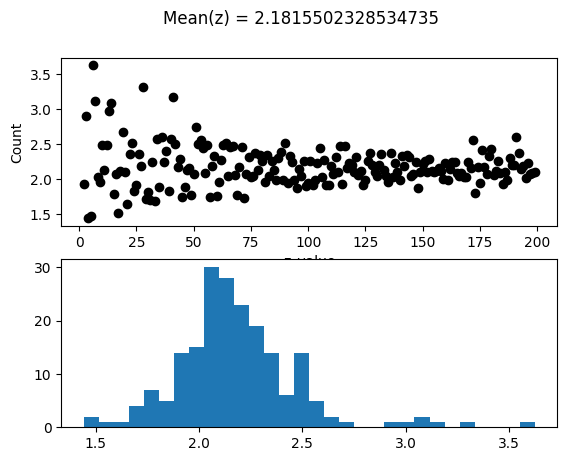

In [510]:
fig_c, ax_c = plt.subplot_mosaic([['plot'],['histogram']])
fig_c.suptitle(f"Mean(z) = {np.nanmean(z_dist)}")

ax_c['plot'].plot(permutations, z_dist, 'ko')
ax_c['plot'].set_xlabel('Number of Permutations')
ax_c['plot'].set_ylabel('Z-value')

ax_c['histogram'].hist(z_dist, bins=30)
ax_c['plot'].set_xlabel('z_value')
ax_c['plot'].set_ylabel('Count')